# Simple Solutions of Fluid Conservation Equations

This notebook covers the content in Lee, *Nuclear Reactor Physics and Engineering*, Section 13.3, pp. 427–430.

The focus is on three introductory fluid-mechanics solutions:

1. Steady 1-D Couette flow between parallel plates.
2. Steady fully developed Hagen–Poiseuille flow in a circular tube.

## 1. Couette flow between two flat plates

**Physical model.** A Newtonian fluid (constant viscosity) occupies the gap between two flat plates. The lower plate moves in the $x$-direction with speed $V$, while the upper plate at $(y=Y)$ is stationary. The flow is steady, one-dimensional, and fully developed:

$$
v_x = v_x(y), \qquad v_y = 0.
$$

Let's first write the Navier-Stokes equation:

$$ 
\rho \left( \frac{\partial \mathbf{v}}{\partial t} + \mathbf{v}\cdot\nabla \mathbf{v} \right)
 = -\nabla p + \mu \nabla^2 \mathbf{v} + \rho \mathbf{g}
$$

Since the flow is steady:

$$
\frac{\partial \mathbf{v}}{\partial t}=0
$$

and since

$$
\mathbf{v}=(v_x(y),0,0)
$$

the convective acceleration is:

$$
\mathbf{v}\cdot\nabla \mathbf{v} = v_x \frac{\partial v_x}{\partial x}
$$

but $v_x$ depends only on $y$, so:

$$
\frac{\partial v_x}{\partial x}=0
$$

And...

$$
\mathbf{v}\cdot\nabla \mathbf{v}=0
$$

So Navier–Stokes reduces to:

$$
0 = -\nabla p + \mu \nabla^2 \mathbf{v}
$$

We really only need to care about the $x$-component of this equation, though, since $v_y = v_z = 0$, which takes us to:

$$
- \frac{\partial p}{\partial x} + \mu \frac{d^2 v_x}{dy^2}=0.
$$

In Classic Couette flow, the flow is **shear-driven only**. There is no imposed pressure difference between inlet and outlet.

So:

$$
\frac{\partial p}{\partial x}=0,
$$

and 

$$
\mu \frac{d^2 v_x}{dy^2}=0.
$$

Now, if we integrate twice with respect to $y$, we find:

$$
v_x(y)=C_1 y + C_2.
$$

The no-slip boundary conditions are

$$
v_x(0)=V, \qquad v_x(Y)=0.
$$

Therefore,

$$
C_2=V,\qquad C_1=-\frac{V}{Y},
$$

and the velocity profile is

$$
\boxed{v_x(y)=V\left(1-\frac{y}{Y}\right)}.
$$

The shear stress is proportional to the velocity gradient:

$$
\tau_{yx}=-\mu \frac{dv_x}{dy}
       = \mu \frac{V}{Y}.
$$

So the shear stress is constant across the gap. This is the basic Newtonian-viscosity result: shear stress is proportional to the rate of strain.


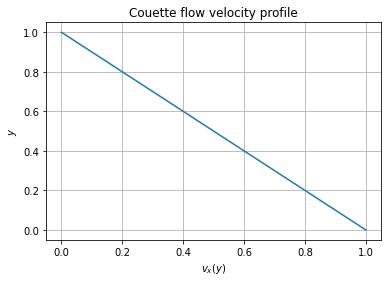

Constant shear stress tau_yx = 1.000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Couette-flow example
V = 1.0      # plate speed
Y = 1.0      # gap height
mu = 1.0     # dynamic viscosity

y = np.linspace(0, Y, 200)
vx = V * (1 - y/Y)
tau_yx = mu * V / Y

plt.figure()
plt.plot(vx, y)
plt.xlabel(r"$v_x(y)$")
plt.ylabel(r"$y$")
plt.title("Couette flow velocity profile")
plt.grid(True)
plt.show()

print(f"Constant shear stress tau_yx = {tau_yx:.3f}")

### 1.5 What if the pressure gradient were not zero?

Then you'd have **Couette–Poiseuille flow**:

$$
0 = -\frac{dp}{dx} + \mu \frac{d^2v_x}{dy^2}
$$

and the velocity profile becomes:

* linear (Couette contribution)
* plus parabolic (Poiseuille contribution)

## 2. Hagen–Poiseuille flow in a circular tube

For a long circular tube of radius $R$ and length $L$, consider steady, fully developed, laminar flow of a Newtonian fluid. The axial velocity depends only on radius:

$$
v_z = v_z(r).
$$

The figure below shows the idealized 1-D pipe-flow geometry.


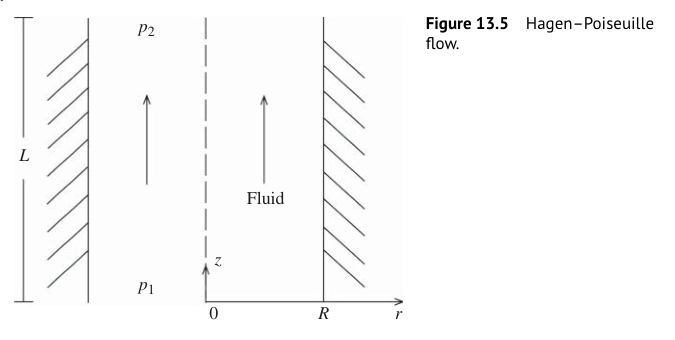

### 2.1 Momentum balance and total pressure

The axial equation of motion for the pipe flow is

$$
\rho v_z \frac{\partial v_z}{\partial z}
=
-\frac{\partial p}{\partial z}
-\frac{1}{r}\frac{\partial}{\partial r}\left(r\tau_{rz}\right)
-\rho g.
$$

For a fully developed flow, $v_z=v_z(r)$, so $\partial v_z/\partial z=0$. This leaves

$$
\frac{1}{r}\frac{d}{dr}\left(r\tau_{rz}\right)
=
-\frac{dp}{dz}-\rho g.
$$

It is useful to combine static pressure and elevation head into a total pressure,

$$
P = p + \rho g z.
$$

Then

$$
-\frac{dP}{dz}
=
\frac{P_1-P_2}{L},
$$

where $P_1$ and $P_2$ are the total pressures at the inlet and outlet. Thus,

$$
\frac{1}{r}\frac{d}{dr}\left(r\tau_{rz}\right)
=
\frac{P_1-P_2}{L}.
$$


### 2.2 Shear-stress distribution

Multiply by $r$:

$$
\frac{d}{dr}\left(r\tau_{rz}\right)
=
\frac{P_1-P_2}{L}r.
$$

Integrate:

$$
r\tau_{rz}
=
\frac{P_1-P_2}{2L}r^2 + C.
$$

Finiteness at \(r=0\) requires \(C=0\), so

$$
\boxed{\tau_{rz}(r)=\frac{P_1-P_2}{2L}r}.
$$

For this sign convention,

$$
\tau_{rz}(r)=-\mu \frac{dv_z}{dr}.
$$

Therefore,

$$
-\mu \frac{dv_z}{dr}
=
\frac{P_1-P_2}{2L}r.
$$


### 2.3 Velocity distribution

Separate and integrate:

$$
\frac{dv_z}{dr}
=
-\frac{P_1-P_2}{2\mu L}r,
$$

$$
v_z(r)
=
-\frac{P_1-P_2}{4\mu L}r^2 + C.
$$

Apply the no-slip condition at the wall, \(v_z(R)=0\):

$$
0=-\frac{P_1-P_2}{4\mu L}R^2+C,
$$

so

$$
C=\frac{P_1-P_2}{4\mu L}R^2.
$$

The parabolic velocity profile is

$$
\boxed{
v_z(r)=
\frac{P_1-P_2}{4\mu L}R^2
\left(1-\frac{r^2}{R^2}\right)
}.
$$


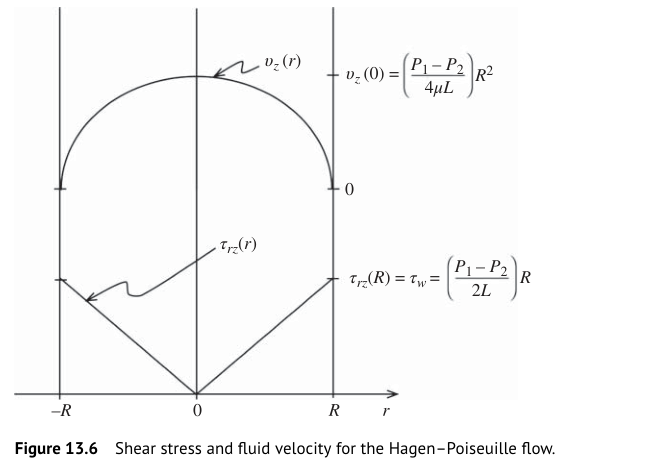

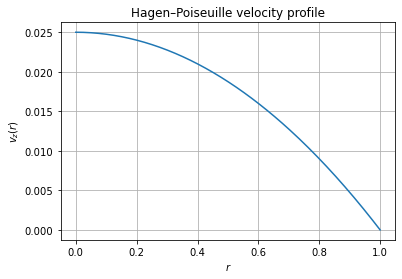

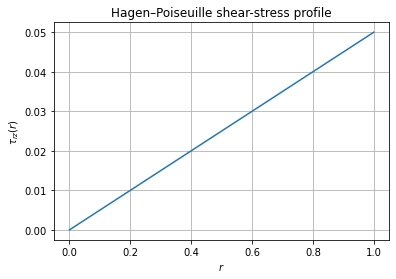

In [2]:
# Hagen-Poiseuille example
R = 1.0
L = 10.0
mu = 1.0
rho = 1.0
DeltaP_total = 1.0  # P1 - P2

r = np.linspace(0, R, 200)
vz = (DeltaP_total/(4*mu*L))*R**2*(1 - (r/R)**2)
tau_rz = (DeltaP_total/(2*L))*r

plt.figure()
plt.plot(r, vz)
plt.xlabel(r"$r$")
plt.ylabel(r"$v_z(r)$")
plt.title("Hagen–Poiseuille velocity profile")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(r, tau_rz)
plt.xlabel(r"$r$")
plt.ylabel(r"$\tau_{rz}(r)$")
plt.title("Hagen–Poiseuille shear-stress profile")
plt.grid(True)
plt.show()

### 2.4 Maximum velocity, average velocity, and mass flow rate

The maximum velocity occurs at the tube centerline:

$$
v_{z,\max}=v_z(0)
=
\frac{P_1-P_2}{4\mu L}R^2.
$$

The average velocity is the cross-sectional area average:

$$
\langle v_z\rangle
=
\frac{2\pi\int_0^R v_z(r)r\,dr}{\pi R^2}.
$$

Substituting the parabolic profile gives

$$
\boxed{
\langle v_z\rangle
=
\frac{P_1-P_2}{8\mu L}R^2
=
\frac{1}{2}v_{z,\max}
}.
$$

The mass flow rate is

$$
W = \rho \langle v_z\rangle \pi R^2,
$$

so

$$
\boxed{
W =
\frac{\pi\rho(P_1-P_2)R^4}{8\mu L}
}.
$$


In [3]:
# Verify the average velocity numerically
area_average_vz = 2*np.trapz(vz*r, r)/R**2
vz_max = vz[0]
mass_flow = rho * area_average_vz * np.pi * R**2

print(f"v_z,max = {vz_max:.6f}")
print(f"<v_z>   = {area_average_vz:.6f}")
print(f"<v_z>/v_z,max = {area_average_vz/vz_max:.6f}")
print(f"Mass flow rate W = {mass_flow:.6f}")

v_z,max = 0.025000
<v_z>   = 0.012500
<v_z>/v_z,max = 0.499987
Mass flow rate W = 0.039269


### 2.5 Pressure drop and Reynolds number

The static pressure drop is separated into frictional and gravitational parts:

$$
\Delta p = p_1-p_2
=
(P_1-P_2)+\rho gL.
$$

Using the mass-flow expression,

$$
\boxed{
\Delta p
=
\frac{8\mu L}{\pi R^4}\frac{W}{\rho}
+
\rho gL
}.
$$

The Reynolds number for pipe flow is

$$
\boxed{
Re = \frac{\rho \langle v_z\rangle D}{\mu}
},
\qquad D=2R.
$$

It measures the relative importance of inertial and viscous effects. In the excerpt, $Re<2100$ is used as the usual laminar-flow classification.


In [4]:
# Reynolds-number calculation
D = 2*R
Re = rho * area_average_vz * D / mu
print(f"Re = {Re:.6f}")

Re = 0.024999
